# FORELÆSNING 9: Lineær regression med populationsdata

> Lineær regression på populationsniveau, modelvalidering, residualanalyse og forudsigelse af kontinuerte udfald.

### Underviser: Martin Siemienski Andersen mvan@hst.aau.dk

**ST2 - Anvendt Programmering**

# ST2 ANVENDT PROGRAMMERING - Overblik

## Alle forelaesninger


In [1]:
from IPython.display import HTML
import requests

url = "https://raw.githubusercontent.com/AAU-ST2-Programming/all_lectures/refs/heads/main/overview_files/shared_overview_table10.html"
html = requests.get(url, timeout=30).text
HTML(html)

#,Forelæsning,Mappe,Primære emner
1,Hej C og Python,oop_1,"Programmeringssprog, grundlæggende syntaks, miljøopsætning"
2,"Objekter, indkapsling, interaktion",oop_2,"Klasser, metoder, dataindkapsling, objektinteraktion"
3,Filer og dataindlæsning,oop_3,Fra tekstfil til objekter
4,OOP-integration workshop,oop_4_workshop,"Integration af OOP, fil-I/O, visualisering; overvågningssystemer til enheder"
5,Signalgrundlag,signals_1,"EKG-fysiologi, statistik, peak-detektion"
6,Filtrering og mekaniske signaler,signals_2,"Filtrering, SCG-fysiologi, mekanisk timing, Envelope-udtrækning"
7,"Feature engineering, PPG og regression",signals_3,"Feature-definition, PPG-fysiologi, lineær regression, variationsmål"
8,Signalintegration og etik,signals_4_workshop,"Multimodal integration, refleksion over signal-workflow, etisk analyse"
9,Review af Python Serial Recorder,python_serial_recorder,"Gennemgang af Python Serial Recorder, diskussion af anvendelser og forbedringer"
10,Lineær regression med populationsdata,populations_data_1,"Lineær regression, modelvalidering, residualer"


# Læringsmål

Efter dagens forelæsning kan du:

**Forstå lineær regression på populationsniveau**
- Anvende regression til at forudsige kontinuerte udfald fra features
- Fortolke hældning, skæring og R²

**Forberede og rense populationsdata**
- Håndtere manglende data og outliers
- Organisere data som NumPy arrays

**Evaluere regressionsmodeller**
- Beregne R², RMSE og residualer
- Validere modelantagelser visuelt

**Implementere multiple lineær regression**
- Bruge flere features som prædiktorer
- Forstå multikollinearitet

**Sikre reproducerbarhed**
- Dokumentere analyse med metadata

# Hvad er lineær regression?

## Definition
Lineær regression finder den **rette linje** der bedst beskriver sammenhængen mellem:
- **X**: prediktor/feature (uafhængig variabel)
- **y**: respons/udfald (afhængig variabel)

## Ligningen
$$y = mx + b$$

hvor:
- $m$ = **hældning** (hvor meget $y$ ændrer sig per enhed $X$)
- $b$ = **skæring** (værdien af $y$ når $X = 0$)

## Linear Regression med Scikit-learn
> ```python
> from scipy.stats import linregress # metode 1
> from sklearn.linear_model import LinearRegression # metode 2
> 
> # Calculate linear regression
> slope, intercept, r_value, p_value, std_err = linregress(x, y) # Metode 1 skipper vi lige idag, for at benytte den mere OOP-venlige metode i sklearn
> ```

## Hvorfor populationsregression?
- Identificer **risikofaktorer** (hvilke features forudsiger sygdom?)
- **Forudsig udfald** for nye individer
- Forstå **sammenhænge** mellem karakteristika

# Reference: sklearn funktioner

## Vigtigste funktioner til lineær regression

### **Model-oprettelse og fitting**
```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)  # X skal være 2D, y skal være 1D
```

### **Udtræk parametre**
```python
m = model.coef_         # Hældning(er) - array
b = model.intercept_    # Skæring - scalar
```

### **Forudsigelser**
```python
y_pred = model.predict(X)         # Forudsig for X
y_new = model.predict(X_new)      # Forudsig for nye data
```

### **Evaluering**
```python
r2 = model.score(X, y)            # R² score
```



### **NumPy helpers**
```python
# Fjern NaN
mask = ~np.isnan(data).any(axis=1)
data_clean = data[mask]

# Beregn RMSE
rmse = np.sqrt(np.mean((y - y_pred)**2))

# Beregn residualer
residuals = y - y_pred
```

# Fra signaler til populationsdata

## Forskel på signalniveau og populationsniveau

| Aspekt | Signalniveau (Forelæsning 5-8) | Populationsniveau (Forelæsning 9-12) |
|--------|-------------------------------|--------------------------------------|
| **Data** | Tidsserier (EKG, PPG, SCG) | Tværsnitsdata (én måling per person) |
| **Struktur** | 1D array (samples over tid) | 2D array (rækker=personer, kolonner=features) |
| **Regression** | Forudsige beat-features fra signalkarakteristika | Forudsige helbredsudfald fra personkarakteristika |
| **Visualisering** | Linjeplot (tid på x-aksen) | Scatter plot (ingen tidsdimension) |
| **Eksempel** | HR fra PPG-amplitude | Blodtryk fra alder og BMI |

# lad os starte med at se på noget data, omkring normale hjertefrekvenser i en population


In [2]:
import numpy as np

# Load the data using numpy with structured array
data = np.genfromtxt('files/synthetic_hr_data.csv', delimiter=',', skip_header=1, 
                      dtype='float,float,float', names='age,gender,heart_rate')

# Extract columns
age = data['age']
gender = data['gender']  # 0 = Female, 1 = Male
heart_rate = data['heart_rate']


# Separate heart rates by gender
females = heart_rate[gender == 0]
males = heart_rate[gender == 1]
 

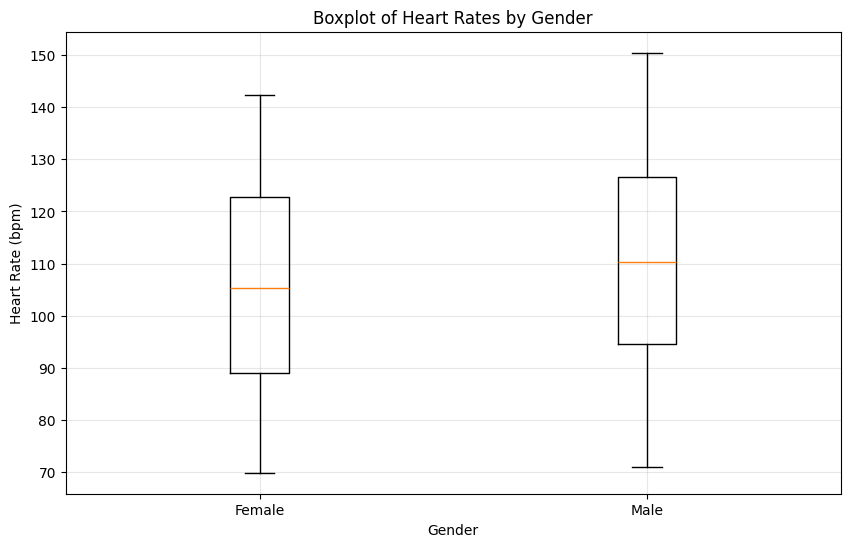

In [3]:

import matplotlib.pyplot as plt
# Plot boxplot of heart rates by gender
plt.figure(figsize=(10, 6))
plt.boxplot([females, males], tick_labels=['Female', 'Male'], vert=True)
plt.title('Boxplot of Heart Rates by Gender')
plt.xlabel('Gender')
plt.ylabel('Heart Rate (bpm)')
plt.grid(True, alpha=0.3)
plt.show()

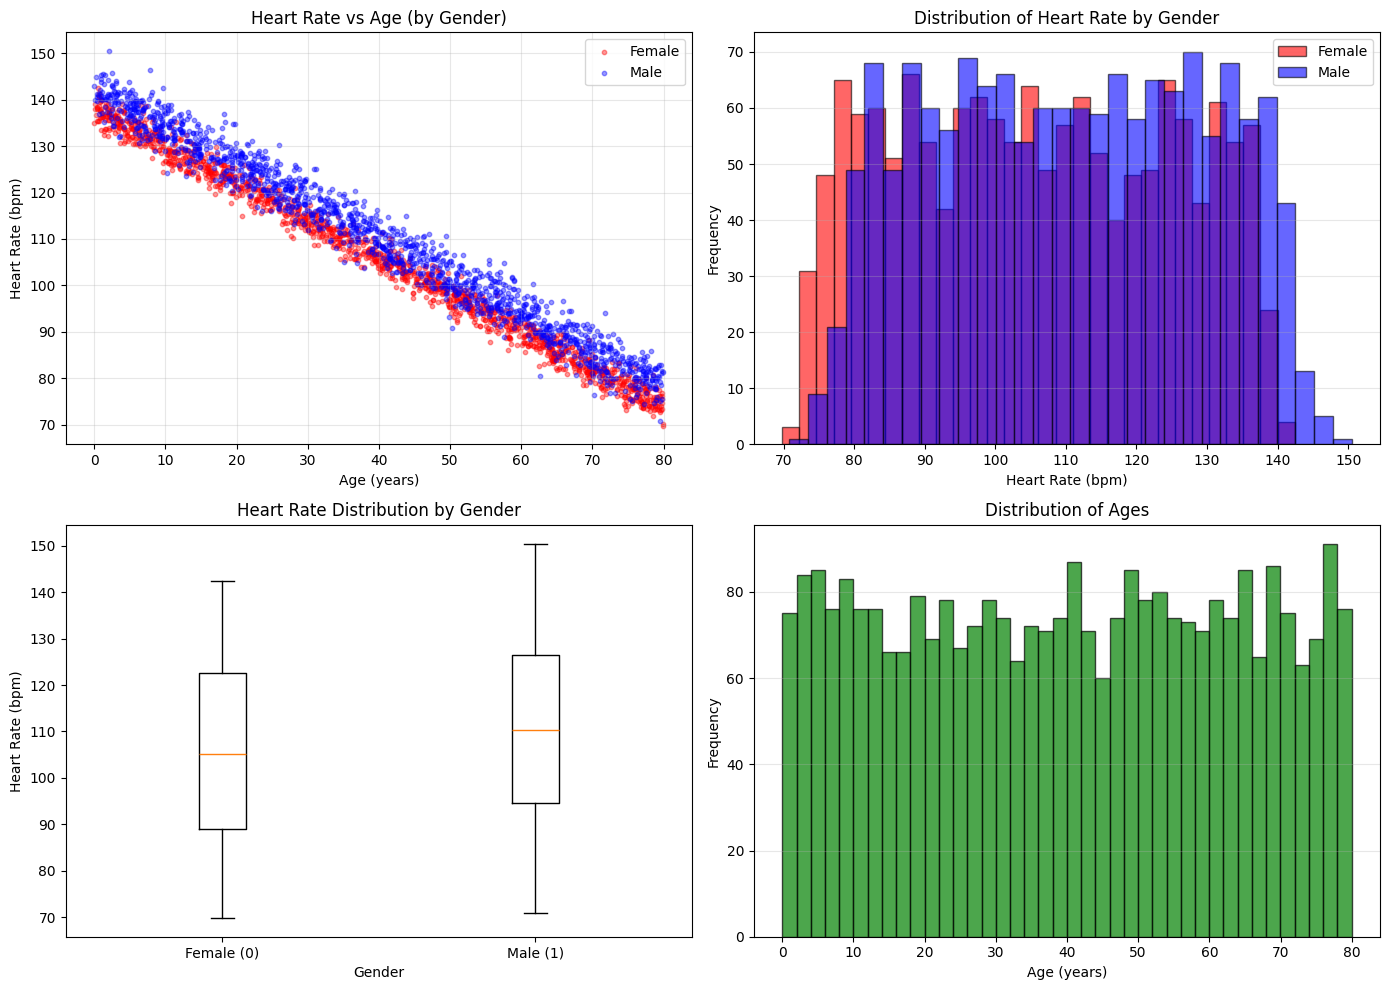

In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Heart Rate vs Age (colored by gender)
females = data[data['gender'] == 0]
males = data[data['gender'] == 1]
axes[0, 0].scatter(females['age'], females['heart_rate'], alpha=0.4, s=10, color='red', label='Female')
axes[0, 0].scatter(males['age'], males['heart_rate'], alpha=0.4, s=10, color='blue', label='Male')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Heart Rate (bpm)')
axes[0, 0].set_title('Heart Rate vs Age (by Gender)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Heart Rate distribution by gender
axes[0, 1].hist(females['heart_rate'], bins=30, alpha=0.6, label='Female', color='red', edgecolor='black')
axes[0, 1].hist(males['heart_rate'], bins=30, alpha=0.6, label='Male', color='blue', edgecolor='black')
axes[0, 1].set_xlabel('Heart Rate (bpm)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Heart Rate by Gender')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Box plot by gender
axes[1, 0].boxplot([females['heart_rate'], males['heart_rate']], 
                    tick_labels=['Female (0)', 'Male (1)'])
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Heart Rate (bpm)')
axes[1, 0].set_title('Heart Rate Distribution by Gender')

# Plot 4: Age distribution
axes[1, 1].hist(data['age'], bins=40, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Ages')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Lineær regression  med scikit learn

In [5]:
# Import nødvendige biblioteker
import numpy as np

# Eksempel: Forudsig systolisk blodtryk fra alder
# Data: [alder (år), systolisk blodtryk (mmHg)]
data = np.array([
    [25, 110], [30, 115], [35, 118], [40, 122], 
    [45, 128], [50, 135], [55, 140], [60, 145],
    [65, 150], [70, 155], [75, 160]
])

# Split i X (prediktor)  og y (respons)
X = data[:, 0:1] # Alder (skal være 2D for sklearn), tænk [[features for patient 0], [features for patient 1...]]
y = data[:, 1]   # Blodtryk (1D array)

print(f"X shape: {X.shape}")  # (11, 1) - 11 personer, 1 feature
print(f"y shape: {y.shape}")  # (11,) - 11 målinger


X shape: (11, 1)
y shape: (11,)


## Trin 2: Fit regressionsmodellen

Nu fitter vi modellen til data ved at finde den bedste linje.

In [6]:

from sklearn.linear_model import LinearRegression
# Opret og fit model
model = LinearRegression()
model.fit(X, y)

# Udtræk parametre
m = model.coef_[0]
b = model.intercept_

print("=" * 50)
print("REGRESSIONSPARAMETRE")
print("=" * 50)
print(f"Hældning (m):     {m:.3f} mmHg/år")
print(f"Skæring (b):      {b:.3f} mmHg")
print(f"\nModelformel:  y = {m:.3f}x + {b:.3f}")
print("=" * 50)

# Fortolkning
print(f"\nFortolkning:")
print(f"   - For hvert år ældre stiger blodtrykket {m:.3f} mmHg")
print(f"   - Ved alder 0 (ekstrapolation) ville BT være {b:.3f} mmHg")

REGRESSIONSPARAMETRE
Hældning (m):     1.025 mmHg/år
Skæring (b):      83.091 mmHg

Modelformel:  y = 1.025x + 83.091

Fortolkning:
   - For hvert år ældre stiger blodtrykket 1.025 mmHg
   - Ved alder 0 (ekstrapolation) ville BT være 83.091 mmHg


## Trin 3: Lav forudsigelser

Brug modellen til at forudsige nye værdier.

In [7]:
# Forudsigelser for træningsdata
y_pred = model.predict(X)

# Forudsigelser for nye aldere
alder_ny = np.array([[32], [48], [63], [25]])  # 3 nye personer
bt_ny = np.array([115,120,140,170])
blodtryk_forudsagt = model.predict(alder_ny)

print("FORUDSIGELSER FOR NYE PERSONER")
print("=" * 50)
for alder, bt in zip(alder_ny.flatten(), blodtryk_forudsagt):
    print(f"Alder {alder} år → Forudsagt BT: {bt:.1f} mmHg")
print("=" * 50)

# Sammenlign faktiske vs forudsagte (træningsdata)
print(f"\nFørste 3 træningspunkter:")
print(f"Faktisk BT:    {bt_ny}")
print(f"Forudsagt BT:  {blodtryk_forudsagt.round(1)}")

FORUDSIGELSER FOR NYE PERSONER
Alder 32 år → Forudsagt BT: 115.9 mmHg
Alder 48 år → Forudsagt BT: 132.3 mmHg
Alder 63 år → Forudsagt BT: 147.7 mmHg
Alder 25 år → Forudsagt BT: 108.7 mmHg

Første 3 træningspunkter:
Faktisk BT:    [115 120 140 170]
Forudsagt BT:  [115.9 132.3 147.7 108.7]


## Trin 4: Visualisér regressionen

Visualisering viser hvor godt linjen fitter data.

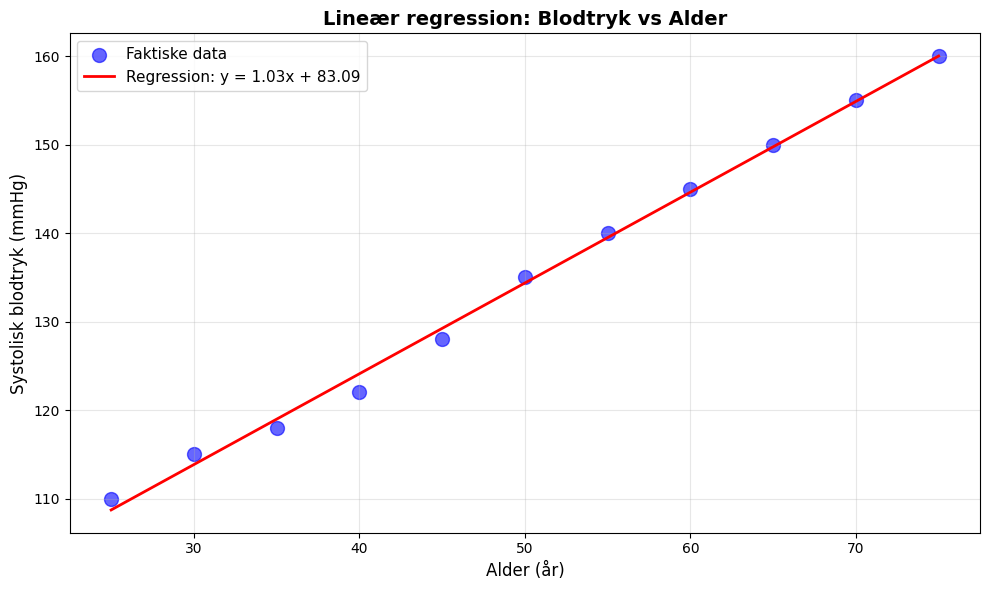

Bemærk:
   - Blå punkter = faktiske målinger
   - Rød linje = den fittede model
   - Jo tættere punkterne er på linjen, jo bedre fit


In [8]:

import matplotlib.pyplot as plt
# Plot data og regressionslinje
plt.figure(figsize=(10, 6))

# Scatter plot af data
plt.scatter(X, y, color='blue', s=100, alpha=0.6, label='Faktiske data')

# Regressionslinje
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regression: y = {m:.2f}x + {b:.2f}')

# Tilpasning
plt.xlabel('Alder (år)', fontsize=12)
plt.ylabel('Systolisk blodtryk (mmHg)', fontsize=12)
plt.title('Lineær regression: Blodtryk vs Alder', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Bemærk:")
print("   - Blå punkter = faktiske målinger")
print("   - Rød linje = den fittede model")
print("   - Jo tættere punkterne er på linjen, jo bedre fit")

# Summarized Guide:

In [9]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)

# Udtræk parametre
m = model.coef_[0]
b = model.intercept_

# Predict
y_pred = model.predict(X)

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Exercise: Brug Linear Regression på at sammenligne features

**Scenarie:**  
Du arbejder som data-analytiker i startupen **PulseLab**, som vil undersøge en sammenhæng mellem puls og systolisk blodtryk i populationsdata.
Teamet har samlet tværsnitsmålinger fra 10 personer, og du skal vurdere om en lineær model beskriver sammenhængen godt.

**Data (10 personer, usorteret rækkefølge):**
>```text
>puls [bpm]: 74, 61, 88, 69, 95, 57, 82, 76, 90, 64
>systolisk blodtryk (mmHg): 123, 110, 136, 118, 142, 106, 129, 124, 138, 113
>```

**Du ved:**  
- Hvordan man laver en linear regressions model
- Hvordan man visualiserer data med scatterplot og regressionslinje
- Hvordan man fortolker `slope`, `intercept`

**Du skal lave et program `files/puls_bt_regression1.py`, der indeholder disse overordnede opgaver:**  
1. **Model og træning:** Opret og fit en lineær regressionsmodel med `LinearRegression` på data.
2. **Analyse af model:** Rapportér `slope`, `intercept`.
3. **Anvendelse af modellen:** Brug modellen til at forudsige systolsk blodtryk ved `puls = 0` og `puls = 88`.
4. **Visualisering:** Lav ét samlet plot med både datapunkter og regressionslinje.

</div>

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

## Answer

Nedenfor er et muligt svar til `files/puls_bt_regression1.py`:

**Kort fortolkning:**
- `slope` viser hvor meget `systolsk blodtryk` forventes at ændre sig, når `puls` stiger med 1 enhed.
- `intercept` er modelens værdi ved `puls = 0` (et matematisk referencepunkt).

</div>


RESULTATER
Slope:     0.9481 mmHg/bpm
Intercept: 52.2234 mmHg
Forudsagt systolisk BT ved puls 0: 52.22 mmHg
Forudsagt systolisk BT ved puls 88: 135.66 mmHg


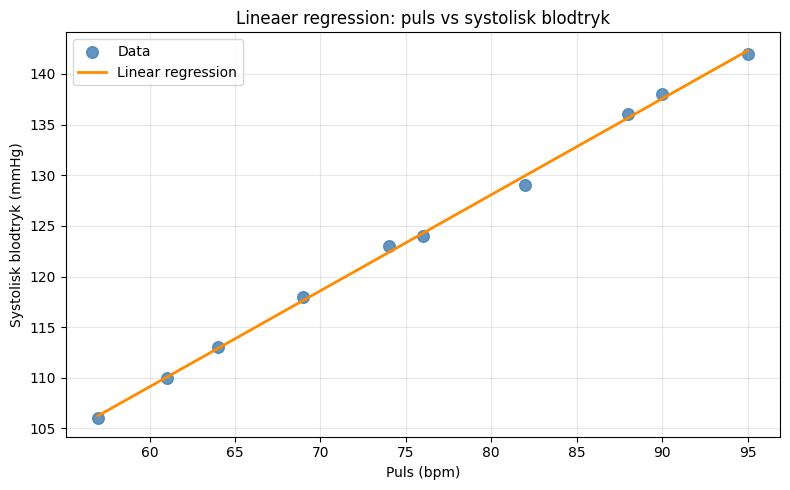

In [10]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data (usorteret populationsrækkefølge)
pulse_bpm = np.array([74, 61, 88, 69, 95, 57, 82, 76, 90, 64])
systolic_bp_mmhg = np.array([123, 110, 136, 118, 142, 106, 129, 124, 138, 113])

# Fit model
regression_model = LinearRegression()
regression_model.fit(pulse_bpm.reshape(-1, 1), systolic_bp_mmhg)

# Parametre
slope_mmhg_per_bpm = regression_model.coef_[0]
intercept_mmhg = regression_model.intercept_
r2_score = regression_model.score(pulse_bpm.reshape(-1, 1), systolic_bp_mmhg)

# Forudsigelser på træningsdata
predicted_systolic_bp_mmhg = regression_model.predict(pulse_bpm.reshape(-1, 1))


print("RESULTATER")
print("=" * 40)
print(f"Slope:     {slope_mmhg_per_bpm:.4f} mmHg/bpm")
print(f"Intercept: {intercept_mmhg:.4f} mmHg")
# Ekstra forudsigelser
new_pulse_values_bpm = np.array([[0], [88]])
predicted_new_systolic_bp_mmhg = regression_model.predict(new_pulse_values_bpm)
for pulse_value, predicted_bp in zip(new_pulse_values_bpm.flatten(), predicted_new_systolic_bp_mmhg):
    print(f"Forudsagt systolisk BT ved puls {pulse_value}: {predicted_bp:.2f} mmHg")

# Plot
sorted_indices = np.argsort(pulse_bpm)
plt.figure(figsize=(8, 5))
plt.scatter(pulse_bpm, systolic_bp_mmhg, color="steelblue", s=70, alpha=0.85, label="Data")
plt.plot(
    pulse_bpm[sorted_indices],
    predicted_systolic_bp_mmhg[sorted_indices],
    color="darkorange",
    linewidth=2,
    label="Linear regression",
)
plt.xlabel("Puls (bpm)")
plt.ylabel("Systolisk blodtryk (mmHg)")
plt.title("Lineaer regression: puls vs systolisk blodtryk")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Modelevaluering

## Hvor godt er fittet?

Vi bruger tre hovedmetrikker:

### 1. **R² (R-squared)**
- Andel af varians forklaret af modellen
- Interval: 0 til 1 (0 = ingen forklaring, 1 = perfekt fit)
- $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$

### 2. **RMSE (Root Mean Squared Error)**
- Gennemsnitlig afstand mellem forudsigelser og data
- Samme enhed som y (mmHg i vores eksempel)
- $\text{RMSE} = \sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$

### 3. **Residualer**
- Forskellen mellem faktisk og predicted: $\text{residual}_i = y_i - \hat{y}_i$
- Bør være tilfældige (ingen mønster)

In [12]:
# Beregn evalueringsmetrikker
r2 = model.score(X, y)  # R² fra sklearn
rmse = np.sqrt(np.mean((y - y_pred)**2))  # RMSE
residuals = y - y_pred  # Residualer

print("=" * 50)
print("MODELEVALUERING")
print("=" * 50)
print(f"R² (R-squared):        {r2:.4f}")
print(f"RMSE:                  {rmse:.2f} mmHg")
print(f"Mean residual:         {np.mean(residuals):.2e} mmHg")
print(f"Std. dev. residuals:   {np.std(residuals):.2f} mmHg")
print("=" * 50)

# Fortolkning
print(f"\nFortolkning:")
print(f"   - R² = {r2:.4f} → Modellen forklarer {r2*100:.1f}% af variansen")
if r2 > 0.9:
    print(f"   - Dette er et MEGET GODT fit!")
elif r2 > 0.7:
    print(f"   - Dette er et GODT fit")
else:
    print(f"   - Dette fit kunne forbedres")
print(f"   - RMSE = {rmse:.2f} mmHg → Typisk forudsigelsefejl")
print(f"   - Residualer har mean ≈ 0 (som forventet)")



MODELEVALUERING
R² (R-squared):        0.9963
RMSE:                  0.99 mmHg
Mean residual:         -1.03e-14 mmHg
Std. dev. residuals:   0.99 mmHg

Fortolkning:
   - R² = 0.9963 → Modellen forklarer 99.6% af variansen
   - Dette er et MEGET GODT fit!
   - RMSE = 0.99 mmHg → Typisk forudsigelsefejl
   - Residualer har mean ≈ 0 (som forventet)


# Residualanalyse

## Hvorfor residualer?

Residualer fortæller os:
- **Hvor godt modellen fitter** (små residualer = godt fit)
- **Om modellen er korrekt** (tilfældig spredning = godt, mønster = problem)
- **Om antagelser holder** (normalitet, homoskedasticitet)

## God vs Dårlig residualfordeling

| God residualfordeling | Dårlig residualfordeling |
|-----------------------|--------------------------|
| Tilfældig spredning omkring 0 | Systematisk mønster (kurve, vifteform) |
| Konstant varians | Variansen stiger/falder med X |
| Omtrent normalfordelt | Skæv fordeling, outliers |

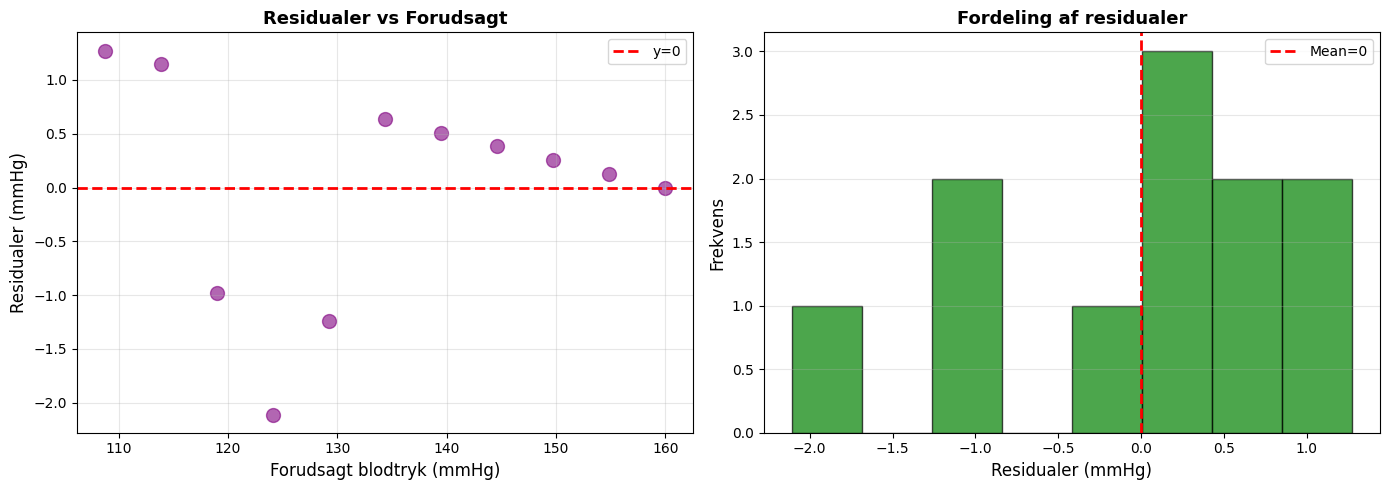

Interpretation:
   - Venstre plot: Tilfældig spredning omkring 0 = godt
   - Højre plot: Omtrent symmetrisk fordeling = godt
   - Hvis der var et mønster, skulle vi bruge en ikke-lineær model


In [13]:
# Visualisér residualer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residualer vs Forudsagt
axes[0].scatter(y_pred, residuals, color='purple', s=100, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='y=0')
axes[0].set_xlabel('Forudsagt blodtryk (mmHg)', fontsize=12)
axes[0].set_ylabel('Residualer (mmHg)', fontsize=12)
axes[0].set_title('Residualer vs Forudsagt', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Histogram af residualer
axes[1].hist(residuals, bins=8, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean=0')
axes[1].set_xlabel('Residualer (mmHg)', fontsize=12)
axes[1].set_ylabel('Frekvens', fontsize=12)
axes[1].set_title('Fordeling af residualer', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("   - Venstre plot: Tilfældig spredning omkring 0 = godt")
print("   - Højre plot: Omtrent symmetrisk fordeling = godt")
print("   - Hvis der var et mønster, skulle vi bruge en ikke-lineær model")

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Exercise (Udvidelse): Residualanalyse af din puls-bt model

**Scenarie:**  
Startupen **PulseLab** kunne godt lide din regressionsanalyse fra `files/puls_bt_regression1.py`,
men teamet mener, at det ville være en god ide at kigge nærmere på **residualerne** og **$R^2$** for at vurdere modelkvaliteten bedre.

Du behøver **ikke** lave hele programmet fra starten igen.
Du kan arbejde videre i dit eksisterende program og udvide det med residualanalyse.

**Du ved:**
- Hvordan man beregner og fortolker R²
- Hvordan man beregner residualer og visualiserer dem

**Data (10 personer, usorteret rækkefølge):**
```text
puls [bpm]: 74, 61, 88, 69, 95, 57, 82, 76, 90, 64
systolisk blodtryk [mmHg]: 123, 110, 136, 118, 142, 106, 129, 124, 138, 113
```

**Udvid dit program (fx i `files/puls_bt_regression1_extension.py`) med disse overordnede opgaver:**
1. **Genbrug modellen:** Fit samme lineære model (puls -> systolisk blodtryk) som i din første løsning.
2. **Beregn modelkvalitet:** Beregn og udskriv **$R^2$**.
4. **Residualanalyse:** Beregn residualer for alle personer og udskriv mindst middelværdi, standardafvigelse
5. **Visualisér residualer:** Lav både (a) residualer vs. forudsagt værdi og (b) histogram af residualer.
6. **Faglig fortolkning:** Skriv en kort tekst (3-6 linjer), hvor du beskriver:
   - Hvad $R^2$ fortæller om modelens forklaringsgrad.
   - Om residualerne ser tilfældige ud omkring 0 eller viser mønster.
   - Om en lineær model virker rimelig for disse data.


</div>

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

## Answer

Kort fortolkning:  
- $R^2$ siger at modellen forklarer næsten 100% af variationen i systolisk blodtryk.
- Residualerne ligger omkring 0 uden tydelig systematisk trend, hvilket understøtter lineær antagelse som første model.
- Spredningen i residualer viser at puls (her) næsten kan forklarer hele variationen.
Nedenfor er et muligt svar til `files/puls_bt_regression1_extension.py`:

</div>

MODELRESULTATER
Slope:                         0.9481 mmHg/bpm
Intercept:                    52.2234 mmHg
R^2:                           0.9985
Residual mean:                -0.0000 mmHg
Residual std:                  0.4484 mmHg


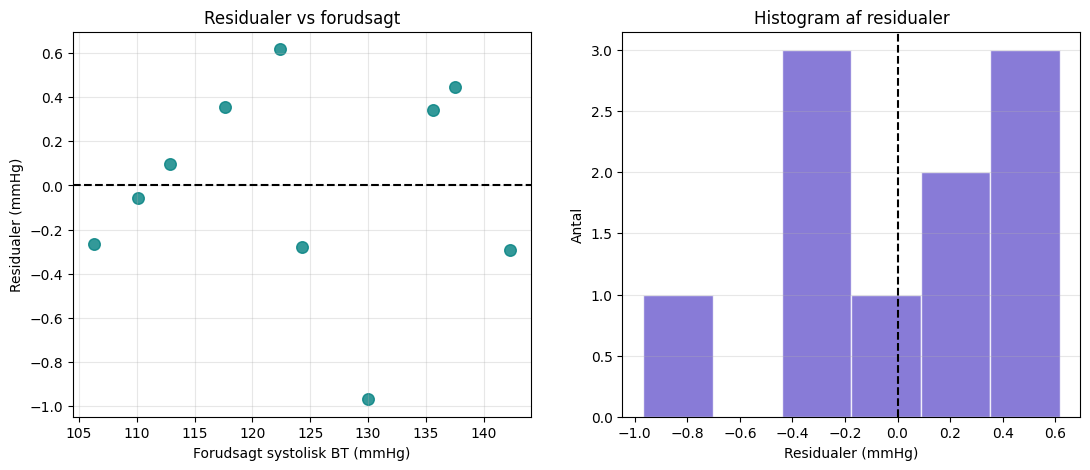

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data (tværsnit, usorteret rækkefølge)
pulse_bpm = np.array([74, 61, 88, 69, 95, 57, 82, 76, 90, 64])
systolic_bp_mmhg = np.array([123, 110, 136, 118, 142, 106, 129, 124, 138, 113])

# Baseline-model (samme ide som i puls_bt_regression1.py)
regression_model = LinearRegression()
regression_model.fit(pulse_bpm.reshape(-1, 1), systolic_bp_mmhg)

# Modelparametre og R2
slope_mmhg_per_bpm = regression_model.coef_[0]
intercept_mmhg = regression_model.intercept_
r2_score = regression_model.score(pulse_bpm.reshape(-1, 1), systolic_bp_mmhg)

# Forudsigelser og residualer
predicted_systolic_bp_mmhg = regression_model.predict(pulse_bpm.reshape(-1, 1))
residuals_mmhg = systolic_bp_mmhg - predicted_systolic_bp_mmhg

residual_mean_mmhg = np.mean(residuals_mmhg)
residual_std_mmhg = np.std(residuals_mmhg)

print("MODELRESULTATER")
print("=" * 50)
print(f"Slope:                {slope_mmhg_per_bpm:15.4f} mmHg/bpm")
print(f"Intercept:            {intercept_mmhg:15.4f} mmHg")
print(f"R^2:                  {r2_score:15.4f}")
print(f"Residual mean:        {residual_mean_mmhg:15.4f} mmHg")
print(f"Residual std:         {residual_std_mmhg:15.4f} mmHg")
print("=" * 50)

# Residualplots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(predicted_systolic_bp_mmhg, residuals_mmhg, color="teal", s=70, alpha=0.8)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Forudsagt systolisk BT (mmHg)")
axes[0].set_ylabel("Residualer (mmHg)")
axes[0].set_title("Residualer vs forudsagt")
axes[0].grid(alpha=0.3)

axes[1].hist(residuals_mmhg, bins=6, color="slateblue", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residualer (mmHg)")
axes[1].set_ylabel("Antal")
axes[1].set_title("Histogram af residualer")
axes[1].grid(alpha=0.3, axis="y")

plt.show()


# Multiple lineær regression

## Fra én til flere features

**Simpel lineær regression:**
$$y = m x + b$$
- Én prediktor (X)

**Multiple lineær regression:**
$$y = m_1 x_1 + m_2 x_2 + m_3 x_3 + ... + m_n x_n + b$$
- Flere prædiktorer ($x_1, x_2, ..., x_n$)

## Eksempel: Blodtryk fra alder OG BMI
$$\text{Blodtryk} = m_1 \cdot \text{Alder} + m_2 \cdot \text{BMI} + b$$

## Fordele
- Mere præcise forudsigelser (højere R²)  
- Forstå relative bidrag fra forskellige faktorer  
- Kontrollere for confounders  

## Udfordringer
- Multikollinearitet (korrelerede features)  
- Overfitting med for mange features  
- Fortolkning bliver mere kompleks

## Multiple regression: Implementering

In [19]:
# Data med flere features: [alder, BMI, systolisk BT]
data_multi = np.array([    
    [25, 22, 110], [30, 24, 115], [35, 23, 118], [40, 26, 122], 
    [45, 28, 128], [50, 30, 135], [55, 29, 140], [60, 31, 145],
    [65, 32, 150], [70, 33, 155], [75, 35, 160]
])
# Split i X (flere features) og y
X_multi = data_multi[:, 0:2]  # Alder og BMI (2 kolonner)
y_multi = data_multi[:, 2]     # Blodtryk

print(f"X_multi shape: {X_multi.shape}") 
print(f"y_multi shape: {y_multi.shape}") 

X_multi shape: (11, 2)
y_multi shape: (11,)


In [20]:
# Fit multiple regression model
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# Udtræk parametre
m1, m2 = model_multi.coef_
b_multi = model_multi.intercept_
print("\n" + "=" * 50)
print("MULTIPLE REGRESSION RESULTAT")
print("=" * 50)
print(f"Koefficient for Alder (m1): {m1:.3f} mmHg/år")
print(f"Koefficient for BMI (m2):   {m2:.3f} mmHg/(kg/m²)")
print(f"Skæring (b):                {b_multi:.3f} mmHg") 
print(f"\nModelformel:")
print(f"BT = {m1:.3f}·Alder + {m2:.3f}·BMI + {b_multi:.3f}")
print("=" * 50)


MULTIPLE REGRESSION RESULTAT
Koefficient for Alder (m1): 0.972 mmHg/år
Koefficient for BMI (m2):   0.211 mmHg/(kg/m²)
Skæring (b):                79.761 mmHg

Modelformel:
BT = 0.972·Alder + 0.211·BMI + 79.761


In [22]:
# Evaluer
y_pred_multi = model_multi.predict(X_multi)
r2_multi = model_multi.score(X_multi, y_multi)
rmse_multi = np.sqrt(np.mean((y_multi - y_pred_multi)**2))

print(f"\nEvaluering:")
print(f"R²:   {r2_multi:.4f} (sammenlign med simple model: {r2:.4f})")
print(f"RMSE: {rmse_multi:.2f} mmHg (sammenlign med simple model: {rmse:.2f} mmHg)")
print(f"\nMultiple regression forbedrer R² med {(r2_multi-r2)*100:.1f}%!... hmm det var ikke meget.")


Evaluering:
R²:   0.9964 (sammenlign med simple model: 0.9963)
RMSE: 0.97 mmHg (sammenlign med simple model: 0.99 mmHg)

Multiple regression forbedrer R² med 0.0%!... hmm det var ikke meget.


# Datahåndtering: Manglende data (NaN)

**Problem:** Reelle datasæt indeholder ofte manglende værdier

**Løsninger:**
1. **Fjern rækker:** Drop personer med manglende data
   ```python
   # Identificér rækker uden NaN
   mask = ~np.isnan(data).any(axis=1)
   data_clean = data[mask]
   ```

2. **Imputation:** Erstat med gennemsnit, median eller forudsigelse
   ```python
   from sklearn.impute import SimpleImputer
   imputer = SimpleImputer(strategy='mean')
   data_imputed = imputer.fit_transform(data)
   ```

# Datahåndtering: Outliers

**Problem:** Ekstreme værdier kan dominere fittet

**Løsninger:**
1. **Boks visualisering:** Inspicer først med box plots!
2. **Z-score metode:** Fjern punkter > 3 standardafvigelser fra middelværdi
3. **IQR metode:** Fjern punkter uden for [Q1-1.5·IQR, Q3+1.5·IQR]

In [23]:
# Eksempel: Data med manglende værdier og outlier
data_messy = np.array([
    [25, 110], [30, 115], [35, np.nan], [40, 122],  # NaN ved alder 35
    [45, 128], [50, 135], [55, 200], [60, 145],     # Outlier (200) ved alder 55
    [65, 150], [70, 155], [75, 160]
])

print("ORIGINAL DATA")
print(data_messy)
print(f"\nAntal NaN: {np.isnan(data_messy).sum()}")

# 1. Håndter manglende data: Fjern rækker med NaN (Kan i komme på andre måder?)
mask = ~np.isnan(data_messy).any(axis=1)
data_no_nan = data_messy[mask]
print(f"\nEfter fjernelse af NaN: {data_no_nan.shape[0]} rækker tilbage")

# 2. Identificér outliers (Z-score > 3)
X_clean = data_no_nan[:, 0].reshape(-1, 1)
y_clean = data_no_nan[:, 1]

z_scores = np.abs((y_clean - np.mean(y_clean)) / np.std(y_clean))
outlier_mask = z_scores < 3  # Behold kun ikke-outliers

X_final = X_clean[outlier_mask]
y_final = y_clean[outlier_mask]

print(f"Efter fjernelse af outliers: {X_final.shape[0]} rækker tilbage")
print(f"Fjernet outlier ved alder: {X_clean[~outlier_mask].flatten()}")

# Fit ren model
model_clean = LinearRegression()
model_clean.fit(X_final, y_final)
r2_clean = model_clean.score(X_final, y_final)

print(f"\nRen model R²: {r2_clean:.4f}")
print(f"   (Sammenlign med oprindelig model: {r2:.4f})")

ORIGINAL DATA
[[ 25. 110.]
 [ 30. 115.]
 [ 35.  nan]
 [ 40. 122.]
 [ 45. 128.]
 [ 50. 135.]
 [ 55. 200.]
 [ 60. 145.]
 [ 65. 150.]
 [ 70. 155.]
 [ 75. 160.]]

Antal NaN: 1

Efter fjernelse af NaN: 10 rækker tilbage
Efter fjernelse af outliers: 10 rækker tilbage
Fjernet outlier ved alder: []

Ren model R²: 0.4810
   (Sammenlign med oprindelig model: 0.9963)


# Etik: Reproducerbarhed og dokumentation

## Hvorfor metadata?

Uden metadata kan analysen ikke verificeres eller genbruges!

## Hvad skal dokumenteres?

### Data-metadata
- Datakilde og indsamlingsdato
- Antal personer, antal features
- Enheder for hver variabel
- Behandlinger udført (fjernet NaN? outliers?)

### Model-metadata
- Model-type (LinearRegression)
- Software-versioner (sklearn, numpy)
- Feature-navne og rækkefølge
- Fit-dato og analytiker

### Resultat-metadata
- R², RMSE og andre metrikker
- Koefficienter og skæring
- Valideringsstrategi (train/test split?)

## Gem metadata i CSV med numpy
>```python
>import numpy as np
>
>metadata = {
>    "date": "2026-02-10",
>    "model": "LinearRegression",
>    "features": ["alder", "BMI"],
>    "n_samples": 11,
>    "r2": 0.9876,
>    "rmse": 2.34
>}
>np.savetxt("metadata.csv", [list(metadata.values())], delimiter=",", header=",".join(metadata.keys()), comments="")
>```

# Komplet workflow: Fra data til model

```
┌─────────────────────────────────────────────────────────────┐
│ 1. INDLÆS DATA                                              │
│    - Læs CSV/NumPy array                                    │
│    - Tjek struktur og dimensioner                           │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 2. INSPICÉR & RENS                                          │
│    - Visualisér med scatter plots                           │
│    - Tjek for manglende data (np.isnan)                     │
│    - Identificér og håndter outliers                        │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 3. FORBERED                                                 │
│    - Split i X (features) og y (respons)                    │
│    - Reshape til korrekte dimensioner                       │
│    - (Optional) Normaliser/standardisér                     │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 4. FIT MODEL                                                │
│    - LinearRegression().fit(X, y)                           │
│    - Udtræk koefficienter og skæring                        │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 5. EVALUER                                                  │
│    - Beregn R², RMSE                                        │
│    - Plot data + regressionslinje                           │
│    - Analyser residualer                                    │
└─────────────────────────────────────────────────────────────┘
                            ↓
┌─────────────────────────────────────────────────────────────┐
│ 6. FORUDSIG & DOKUMENTÉR                                    │
│    - Brug model.predict() på nye data                       │
│    - Gem resultater med metadata                            │
│    - Rapportér resultater                                   │
└─────────────────────────────────────────────────────────────┘
```

# Lineær regressions antagelser
For at regression skal være valid, skal følgende holde:

### 1. **Linearitet**
- Sammenhængen mellem X og y skal være lineær
- Tjek: Plot data først!

### 2. **Uafhængighed**
- Observationer skal være uafhængige
- Problem: gentagne målinger på samme person

### 3. **Homoskedasticitet**
- Varians af residualer skal være konstant
- Tjek: Residualplot ikke-vifteformet

### 4. **Normalitet** (Ikke på dette semester)
- Residualer bør være normalfordelte
- Tjek: Histogram eller Q-Q plot

# Lineær regressions Begrænsninger

**Korrelation ≠ kausalitet**
- Regression viser sammenhæng, ikke årsag

**Ekstrapolering er usikker**
- Forudsigelser uden for data-området er upålidelige

**Multikollinearitet**
- Korrelerede features gør koefficienter ustabile

**Outliers dominerer**
- Få ekstreme punkter kan ændre fittet drastisk


# Almindelige fejl
- Glemme at reshape X til 2D array  (scikit learn)
- Bruge træningsdata til evaluering  
- Ignorere outliers og NaN  
- Antage kausalitet fra korrelation  
- Ekstrapolere langt fra data  
- Glemme metadata (hvordan blev modellen fittet?)

# Praktiske tips

## Gode vaner

### **Visualisér ALTID data først**
- Scatter plot afslører relationer og outliers
- Aldrig fit en model uden at se data

### **Start simpelt**
- Prøv simple lineær regression før multiple
- Tilføj features én ad gangen

### **Validér antagelser**
- Tjek residualplots efter hvert fit
- Hvis mønster: overvej ikke-lineær model

### **Dokumentér alt**
- Gem metadata sammen med resultater
- Kommentér kode grundigt
- Rapportér både succesfulde og mislykkede forsøg

### **Fortolk i kontekst**
- R² alene er ikke nok
- Spørg: Giver resultaterne fysiologisk/klinisk mening?


# Etiske overvejelser

## Populationsdata er følsomme helbredsdata

### Privatlivsbeskyttelse
- **Pseudonymisering:** Ingen direkte identifikatorer (navne, CPR-numre)
- **Adgangskontrol:** Kun autoriserede personer ser data
- **Kryptering:** Data skal være krypteret både i hvile og under transport

### Bias og retfærdighed
- **Repræsentativitet:** Er din population repræsentativ?
- **Underrepræsentation:** Visse grupper kan mangle i data
- **Fairness:** Sikr at modellen ikke diskriminerer på køn, etnicitet, alder

### Samtykke og transparens
- **Informeret samtykke:** Personer skal vide hvordan data bruges
- **Formålsbegrænsning:** Brug kun data til det aftalte formål
- **Retten til at blive glemt:** Personer kan trække samtykke tilbage

### Ansvarlig brug af forudsigelser
- **Usikkerhed kommunikeres:** RMSE og konfidensintervaller skal rapporteres
- **Begrænsninger ekspliciteres:** Ikke ekstrapolér, rapportér antagelser
- **Klinisk validering:** Modeller skal testes prospektivt før deployment

### Refleksion
> Når vi forudsiger helbredsudfald, påvirker vi virkelige menneskers liv.  
> Spørg altid: Er dette etisk forsvarligt? Er det til gavn for patienten?

# Exercises


<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Exercise: Prøv selv - diastolisk blodtryk fra puls

**Scenarie:**  
Du arbejder som data-analytiker i startupen **PulseLab**, som vil undersøge om puls kan bruges til at forudsige diastolisk blodtryk i en lille population.
Teamet har samlet målinger fra 8 personer og vil have en hurtig regressionsanalyse som første model.

**Data (8 personer):**
```text
puls [bpm]: 60, 65, 70, 75, 80, 85, 90, 95
diastolisk blodtryk [mmHg]: 70, 72, 75, 78, 80, 83, 85, 88
```

**Du ved:**  
- Hvordan man bygger en lineær model med `LinearRegression`
- Hvordan man visualiserer data med scatterplot og regressionslinje
- Hvordan man evaluerer modellen med $R^2$, RMSE og residualer

**Opgave:**
1. Fit en lineær regressionsmodel for puls -> diastolisk blodtryk.
2. Visualisér datapunkter og regressionslinje i samme figur.
3. Beregn og rapportér `slope`, `intercept`, $R^2$ og RMSE.
4. Lav residualanalyse (residualplot og kort vurdering af om residualerne virker tilfældige).
5. Brug modellen til at forudsige diastolisk blodtryk ved puls = 72 bpm.

**Udvidelse (valgfrit):**
- Tilføj BMI som ekstra feature og undersøg om $R^2$ forbedres.

Data til udvidelsen:
```text
[puls, BMI, diastolisk blodtryk]
[60, 22, 70], [65, 24, 72], [70, 23, 75], [75, 26, 78],
[80, 28, 80], [85, 30, 83], [90, 29, 85], [95, 31, 88]
```

</div>

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

## Answer

Nedenfor er et muligt svar til øvelsen:

- `slope` og `intercept` beskriver den lineære sammenhæng mellem puls og diastolisk blodtryk.
- $R^2$ viser hvor stor en andel af variationen i blodtryk modellen forklarer.
- RMSE viser den typiske fejl i mmHg.
- Residualerne bruges til at vurdere, om en lineær model er rimelig (tilfældig spredning omkring 0 er et godt tegn).

</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data (8 personer)
pulse_bpm = np.array([60, 65, 70, 75, 80, 85, 90, 95])
diastolic_bp_mmhg = np.array([70, 72, 75, 78, 80, 83, 85, 88])

# Fit lineaer regressionsmodel
regression_model = LinearRegression()
regression_model.fit(pulse_bpm.reshape(-1, 1), diastolic_bp_mmhg)

# Parametre
slope_mmhg_per_bpm = regression_model.coef_[0]
intercept_mmhg = regression_model.intercept_
r2_score = regression_model.score(pulse_bpm.reshape(-1, 1), diastolic_bp_mmhg)

# Forudsigelser paa traeningsdata
predicted_diastolic_bp_mmhg = regression_model.predict(pulse_bpm.reshape(-1, 1))

# RMSE og residualer
rmse_mmhg = np.sqrt(np.mean((diastolic_bp_mmhg - predicted_diastolic_bp_mmhg) ** 2))
residuals_mmhg = diastolic_bp_mmhg - predicted_diastolic_bp_mmhg

print("RESULTATER")
print("=" * 50)
print(f"Slope:     {slope_mmhg_per_bpm:.4f} mmHg/bpm")
print(f"Intercept: {intercept_mmhg:.4f} mmHg")
print(f"R^2:       {r2_score:.4f}")
print(f"RMSE:      {rmse_mmhg:.4f} mmHg")
print(f"Residual mean: {np.mean(residuals_mmhg):.4f} mmHg")
print(f"Residual std:  {np.std(residuals_mmhg):.4f} mmHg")
print("=" * 50)

# Forudsig ved puls = 72 bpm
predicted_at_72 = regression_model.predict(np.array([[72]]))[0]
print(f"\nForudsagt diastolisk blodtryk ved puls 72 bpm: {predicted_at_72:.2f} mmHg")

# Plot 1: data + regressionslinje
plt.figure(figsize=(8, 5))
plt.scatter(pulse_bpm, diastolic_bp_mmhg, s=80, alpha=0.85, color="steelblue", label="Data")
plt.plot(pulse_bpm, predicted_diastolic_bp_mmhg, color="darkorange", linewidth=2, label="Lineaer regression")
plt.xlabel("Puls (bpm)")
plt.ylabel("Diastolisk blodtryk (mmHg)")
plt.title("Lineaer regression: puls vs diastolisk blodtryk")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: residualplot
plt.figure(figsize=(8, 5))
plt.scatter(predicted_diastolic_bp_mmhg, residuals_mmhg, s=80, alpha=0.85, color="purple")
plt.axhline(0, color="black", linestyle="--", linewidth=1.5)
plt.xlabel("Forudsagt diastolisk blodtryk (mmHg)")
plt.ylabel("Residualer (mmHg)")
plt.title("Residualer vs forudsagt")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Kort vurdering
print("\nKort vurdering:")
print(f"- R^2 = {r2_score:.3f}, dvs. modellen forklarer cirka {r2_score*100:.1f}% af variationen.")
print("- Residualerne ligger taet omkring 0 uden tydeligt moenster, saa en lineaer model virker rimelig her.")

<div style="background-color: rgba(255, 253, 231, 0.2); padding: 30px; border-radius: 10px; border-left: 5px solid #fbc02d;">

# Exercise: Påvirker hjertefrekvensen (RR-interval) R-bølgens amplitude i EKG Version 2.0?

**Scenarie:**  
Du er data-ingeniør i startupen **BeatBusters**, der bygger en “stress-detektor” til studerende før eksamen.
Teamet påstår, at når pulsen stiger, så ændrer R-peak amplituden sig lineært, og at denne ændring er den samme mellem baseline og når forsøgspersoner lytter til klasisk musik.
Din mission er at teste om deres hype holder i virkeligheden ved hjælp af en regressionsanalyse.  
Du har 2 datasæt
- Baseline: `files/features_table_b001.csv` 
- Musik: `files/features_table_m001.csv`

**Du ved:**  
- Hvordan man henter features fra en CSV
- Hvordan man laver scatterplot og lineær regression
- Hvordan man tolker slope, $R^2$ og residualer

**Du skal lave et program `files/music_vs_baseline_2.py`:**  
1. Tilpas en lineær regressions model på `RR` og `R_amp` fra `files/features_table_b001.csv` eller `files/features_table_m001.csv`
2. Lav et scatterplot af input-features mod output-features og  og plot regressionslinjen i samme plot
3. Sammenlign baseline vs music og vurder om relationen ændrer sig mellem betingelser
4. Rapportér `slope`, `intercept`, samt R2 og residualer og beskriv hvad de betyder.

</div>

<div style="background-color: rgba(200, 240, 200, 0.3); padding: 20px; border-radius: 10px; border-left: 5px solid #66bb6a;">

## Answer

**4) Rapportér `slope`, `intercept`, $R^2$ og modelkvalitet**

Ud fra lineær regression på `RR` -> `R_amp`:

- **Baseline**:
  - `slope = 0.5495`
  - `intercept = 0.6319`
  - $R^2 = 0.1918$

- **Music**:
  - `slope = 0.2379`
  - `intercept = 0.8756`
  - $R^2 = 0.1488$

**Kort vurdering af modelkvalitet:**
- Begge slopes er positive (R_amp stiger svagt med RR).
- Men $R^2$ er lav i begge tilfælde (~0.15–0.19), så den lineære model forklarer kun en mindre del af variationen.
- Modellen kan bruges som en simpel trend-beskrivelse, men ikke som stærk prædiktiv model alene.

**5) Residual-plot og lineær antagelse**

- Residualer er centreret omkring 0 (middel tæt på 0 i begge grupper).
- Der ses ikke systematisk lineær trend mellem `RR` og residualer.
- Den lineære antagelse er derfor **rimelig som første approximation**, men den lave $R^2$ viser, at andre faktorer/nonlinearitet stadig bidrager væsentligt.

</div>

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
import numpy as np

# Load file with NumPy and ignore missing values
RR_b, R_amp_b = np.genfromtxt('files/features_table_b001.csv', delimiter=',', skip_header=1, dtype=float, usecols=(0, 1), unpack=True)
# Header is RR,R_amp,RtoS2,S1toS2,Resp_amp,Resp_amp_RR_Rmean,Resp__amp_RR_std
mask = ~np.isnan(RR_b) & ~np.isnan(R_amp_b)
RR_b = RR_b[mask]
R_amp_b = R_amp_b[mask]

# Select features
RR_m, R_amp_m = np.genfromtxt('files/features_table_m001.csv', delimiter=',', skip_header=1, dtype=float, usecols=(0, 1), unpack=True)
# Header is RR,R_amp,RtoS2,S1toS2,Resp_amp,Resp_amp_RR_Rmean,Resp__amp_RR_std
mask = ~np.isnan(RR_m) & ~np.isnan(R_amp_m)
RR_m = RR_m[mask]
R_amp_m = R_amp_m[mask] 

labels = ["music", "baseline"]
RR_all = [RR_m, RR_b]
R_amp_all = [R_amp_m, R_amp_b]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Create plots for baseline and music with their own colors
for label, rr, r_amp in zip(labels, RR_all, R_amp_all):
    assert isinstance(rr, np.ndarray) and isinstance(r_amp, np.ndarray) , "Inputs must be numpy arrays, was: {}, {}".format(type(rr), type(r_amp))
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(rr, r_amp)
    alder = np.array([min(rr), max(rr)])
    y = intercept + slope * alder

    # visualization
    # scatter with regression line
    ax1.scatter(rr, r_amp, alpha=0.3*1000/(1000+len(rr)), edgecolor='w')
    ax1.plot(alder, y, linewidth=2, label=f'{label} fit: y={slope:.2f}x+{intercept:.2f}, $R^2$={r_value**2:.2f}')  # type: ignore # Add the regression line   

    # # residuals
    ax2.scatter(rr, r_amp - (slope * rr + intercept), alpha=0.3*1000/(1000+len(rr)))

# Finalize plots
ax1.set_xlabel("RR Intervals")
ax1.set_ylabel("R Amplitude (a.u.)")
ax1.set_title("RR Intervals vs R Amplitude with Linear Regression")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.set_xlabel("RR Intervals")
ax2.set_ylabel("Residuals of R Amplitude")
ax2.set_title("Residuals of Linear Regression")
ax2.grid(True, alpha=0.3)


plt.show()